In [1]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Stable Diffusion pipeline loaded successfully.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion pipeline loaded successfully.


In [2]:
print(pipe.tokenizer)
print(pipe.text_encoder)
print(pipe.unet)
print(pipe.scheduler)
print(pipe.vae)

CLIPTokenizer(name_or_path='/root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/tokenizer', vocab_size=49408, model_max_length=77, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|startoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	49406: AddedToken("<|startoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	49407: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)
CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_

In [4]:
prompt = "A futuristic cyberpunk city"

tokens = pipe.tokenizer(
    prompt,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[49406,   320, 30987, 36896,  1305, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}


In [5]:
with torch.no_grad():

    embeddings = pipe.text_encoder(
        tokens.input_ids.to("cuda")
    )[0]

print(embeddings.shape)

torch.Size([1, 6, 768])


  0%|          | 0/50 [00:00<?, ?it/s]

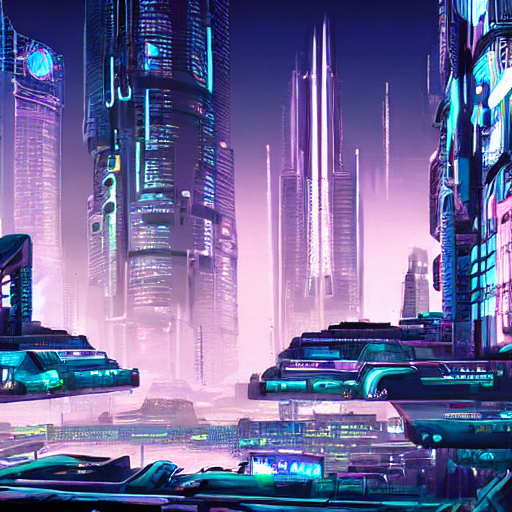

In [6]:
image = pipe(prompt).images[0]

image

In [7]:
from torchvision import transforms

transform = transforms.ToTensor()

image_tensor = transform(image).unsqueeze(0).to("cuda").half()

latent = pipe.vae.encode(image_tensor).latent_dist.sample()

print(latent.shape)

torch.Size([1, 4, 64, 64])


# Full Stable Diffusion Flow

1. Prompt is tokenized
2. Tokens become CLIP embeddings
3. Noise is initialized in latent space
4. UNet performs denoising
5. Cross-attention aligns text and image semantics
6. Scheduler controls timestep progression
7. VAE decodes latent representation into final image

# Stable Diffusion Architecture

                Prompt
                   ↓
              Tokenizer
                   ↓
           CLIP Embeddings
                   ↓
         Cross-Attention
                   ↓
            UNet Denoising
                   ↓
              Scheduler
                   ↓
            Latent Space
                   ↓
              VAE Decode
                   ↓
             Final Image